In [4]:
from moviepy.editor import AudioFileClip
import noisereduce as nr
import scipy.io.wavfile as wavfile
import numpy as np

input_path = r"C:\Users\DELL\OneDrive\Desktop\Resume projects\project-ezip\project-e\data1\samsung laptop.m4a"
output_path = r"C:\Users\DELL\OneDrive\Desktop\Resume projects\project-ezip\project-e\data1\amazon_samsung.wav"
cleaned_path = r"C:\Users\DELL\OneDrive\Desktop\Resume projects\project-ezip\project-e\data1\amazon_samsung_cleaned.wav"

# :white_check_mark: Convert m4a → wav
clip = AudioFileClip(input_path)
clip.write_audiofile(output_path)

# :white_check_mark: Apply Noise Reduction
rate, data = wavfile.read(output_path)
if len(data.shape) == 2:
    data = data[:, 0]
reduced_noise = nr.reduce_noise(y=data, sr=rate)
wavfile.write(cleaned_path, rate, reduced_noise.astype(np.int16))

print(":white_check_mark: Cleaned audio saved at:", cleaned_path)


MoviePy - Writing audio in C:\Users\DELL\OneDrive\Desktop\Resume projects\project-ezip\project-e\data1\amazon_samsung.wav


MoviePy - Done.
:white_check_mark: Cleaned audio saved at: C:\Users\DELL\OneDrive\Desktop\Resume projects\project-ezip\project-e\data1\amazon_samsung_cleaned.wav


In [5]:
import os
import imageio_ffmpeg
# Get the actual ffmpeg path from imageio-ffmpeg and add it to system path
ffmpeg_path = os.path.dirname(imageio_ffmpeg.get_ffmpeg_exe())
os.environ["PATH"] += os.pathsep + ffmpeg_path
# Confirm it's in the path
print(":white_check_mark: FFmpeg path added:", ffmpeg_path)

:white_check_mark: FFmpeg path added: C:\Users\DELL\anaconda3\envs\classification\lib\site-packages\imageio_ffmpeg\binaries


In [6]:
import os
import imageio_ffmpeg
# Get the actual ffmpeg path from imageio-ffmpeg and add it to system path
ffmpeg_path = os.path.dirname(imageio_ffmpeg.get_ffmpeg_exe())
os.environ["PATH"] += os.pathsep + ffmpeg_path
# Confirm it's in the path
print(":white_check_mark: FFmpeg path added:", ffmpeg_path)

import whisper
import pandas as pd
import subprocess
import imageio_ffmpeg
# Set FFmpeg path (required by whisper for audio loading)
whisper.audio.FFMPEG_PATH = imageio_ffmpeg.get_ffmpeg_exe()
def patched_load_audio(file, sr=16000):
    cmd = [
        whisper.audio.FFMPEG_PATH,
        "-nostdin", "-threads", "0",
        "-i", file,
        "-f", "f32le",
        "-acodec", "pcm_f32le",
        "-ac", "1",
        "-ar", str(sr), "-"
    ]
    out = subprocess.run(cmd, capture_output=True, check=True).stdout
    return whisper.audio.np.frombuffer(out, dtype=whisper.audio.np.float32)
whisper.audio.load_audio = patched_load_audio
# Load Whisper model
model = whisper.load_model("medium")
# Path to your audio file
audio_path =  r"C:\Users\DELL\OneDrive\Desktop\Resume projects\project-ezip\project-e\data1\amazon_samsung_cleaned.wav"
# Transcribe with timestamps
result = model.transcribe(audio_path, word_timestamps=False)
segments = result['segments']
# Keywords to identify speakers
agent_keywords = [
    "assist", "order id", "welcome", "amazon", "sorry", "thank you", "please", "pickup", "replacement",
    "invoice", "confirm", "warranty", "request", "exchange", "shipping", "process", "tracking", "delivery",
     "name", "email", "phone", "Address","quick response","transit","new replacement","immediately","business days",
    "original box","pick up personal will assist","restarts","if needed","contact","new laptop","great day","phone","name","email","photo attached"
]
customer_keywords = [
    "disappointed", "cracked", "received", "worried", "thank you", "sure", "photo", "pack", "valid",
    "raise", "helpful", "priyamshu", "i'm", "my","complicated","should","myself","hand it over",
    "warranty","valid","new unit","hashtag","gmail.com","verma","convey","lucknow","89876001122","yeah"
]
def identify_speaker(text):
    text_lower = text.lower()
    agent_score = sum(k in text_lower for k in agent_keywords)
    customer_score = sum(k in text_lower for k in customer_keywords)
    if agent_score > customer_score:
        return "Sindhu (Agent)"
    elif customer_score > agent_score:
        return "Priyamshu (Customer)"
    else:
        return None
# Assign speakers to segments, but apply improved fallback logic:
#  - Use last speaker if uncertain to avoid flipping
#  - Only alternate if no last speaker (first segment)
labeled_segments = []
last_speaker = None
for seg in segments:
    speaker = identify_speaker(seg['text'])
    if speaker is None:
        if last_speaker is None:
            speaker = "Sindhu (Agent)"  # default start
        else:
            speaker = last_speaker  # keep same speaker to avoid flip-flop
    labeled_segments.append({
        "speaker": speaker,
        "start": seg["start"],
        "end": seg["end"],
        "text": seg["text"].strip()
    })
    last_speaker = speaker
# Merge consecutive segments by same speaker to keep flow smooth
merged_segments = []
prev = labeled_segments[0]
for curr in labeled_segments[1:]:
    # If same speaker and gap between segments is small, merge
    time_gap = curr["start"] - prev["end"]
    if curr["speaker"] == prev["speaker"] and time_gap < 1.5:
        prev["end"] = curr["end"]
        prev["text"] += " " + curr["text"]
    else:
        merged_segments.append(prev)
        prev = curr
merged_segments.append(prev)
# Save full corrected conversation
dfnew = pd.DataFrame(merged_segments)
output_csv =  r"C:\Users\DELL\OneDrive\Desktop\Resume projects\project-ezip\project-e\data1\transcription_corrected.csv"
dfnew.to_csv(output_csv, index=False)
print(f"Full corrected transcription saved to: {output_csv}")
print(dfnew)


:white_check_mark: FFmpeg path added: C:\Users\DELL\anaconda3\envs\classification\lib\site-packages\imageio_ffmpeg\binaries
Full corrected transcription saved to: C:\Users\DELL\OneDrive\Desktop\Resume projects\project-ezip\project-e\data1\transcription_corrected.csv
                 speaker   start     end  \
0         Sindhu (Agent)    0.00    7.44   
1   Priyamshu (Customer)    7.44   15.00   
2         Sindhu (Agent)   15.00   28.00   
3   Priyamshu (Customer)   28.00   29.00   
4         Sindhu (Agent)   29.00   32.00   
5   Priyamshu (Customer)   32.00   40.00   
6         Sindhu (Agent)   40.00   41.00   
7   Priyamshu (Customer)   41.00   42.00   
8         Sindhu (Agent)   42.00   43.00   
9   Priyamshu (Customer)   43.00   46.00   
10        Sindhu (Agent)   46.00   47.00   
11  Priyamshu (Customer)   47.00   67.00   
12        Sindhu (Agent)   67.00   76.00   
13  Priyamshu (Customer)   76.00   81.00   
14        Sindhu (Agent)   82.00   97.00   
15  Priyamshu (Customer)   97

In [7]:
import pandas as pd
# Load the transcript CSV
file_path = r"C:\Users\SREE GANESHA\Desktop\ORIGINAL PROJECTS\audioporjectbasedonecom\data1\transcription_corrected.csv"
df = pd.read_csv(file_path)
# Find the index of the mixed line
search_text = "Handstack 32, Trinacres, Covney, Lucknow Photo attached?"
mixed_index = df[df["text"].str.contains(search_text, na=False)].index[0]
# Extract start time for use
start_time = df.loc[mixed_index, "start"]
next_line_text = df.loc[mixed_index + 1, "text"]
end_time = df.loc[mixed_index + 1, "end"]
# Construct new rows
new_rows = [
    {
        "speaker": "Priyamshu (Customer)",
        "start": start_time,
        "end": start_time + 1,AC
        "text": "Handstack 32, Trinacres, Covney, Lucknow"
    },
    {
        "speaker": "Sindhu (Agent)",
        "start": start_time + 1,
        "end": start_time + 2,
        "text": "Photo attached?"
    },
    {
        "speaker": "Priyamshu (Customer)",
        "start": start_time + 2,
        "end": start_time + 3,
        "text": "Yeah"
    },
    {
        "speaker": "Sindhu (Agent)",
        "start": start_time + 3,
        "end": end_time,
        "text": "Thanks for the quick response Priyam Shu. I have reviewed the photo and the order. " + next_line_text
    }
]
# Drop the mixed row
df.drop(index=mixed_index, inplace=True)
# Drop the next line since it is now merged
df.drop(index=mixed_index + 1, inplace=True)
# Insert new rows
df_before = df.iloc[:mixed_index]
df_after = df.iloc[mixed_index:]
df = pd.concat([df_before, pd.DataFrame(new_rows), df_after], ignore_index=True)
# Save the cleaned transcript
output_path = r"C:\Users\SREE GANESHA\Desktop\ORIGINAL PROJECTS\audioporjectbasedonecom\data1\transcription_cleaned_final1.csv"
df.to_csv(output_path, index=False)
output_path

SyntaxError: invalid syntax (3519606468.py, line 18)

In [8]:
import pandas as pd

# Load the transcript CSV
file_path = r"C:\Users\DELL\OneDrive\Desktop\Resume projects\project-ezip\project-e\data1\transcription_corrected.csv"
df = pd.read_csv(file_path)

# Step 1: Identify the index of the mixed line
search_text = "Handstack 32, Trinacres, Covney, Lucknow Photo attached?"
mixed_index = df[df["text"].str.contains(search_text, na=False)].index[0]

# Step 2: Extract start and end times
start_time = df.loc[mixed_index, "start"]
next_line_text = df.loc[mixed_index + 1, "text"]
end_time = df.loc[mixed_index + 1, "end"]

# Step 3: Construct corrected rows
new_rows = [
    {
        "speaker": "Priyamshu (Customer)",
        "start": start_time,
        "end": start_time + 1,
        "text": "Handstack 32, Trinacres, Covney, Lucknow"
    },
    {
        "speaker": "Sindhu (Agent)",
        "start": start_time + 1,
        "end": start_time + 2,
        "text": "Photo attached?"
    },
    {
        "speaker": "Priyamshu (Customer)",
        "start": start_time + 2,
        "end": start_time + 3,
        "text": "Yeah"
    },
    {
        "speaker": "Sindhu (Agent)",
        "start": start_time + 3,
        "end": end_time,
        "text": "Thanks for the quick response Priyam Shu. I have reviewed the photo and the order. " + next_line_text
    }
]

# Step 4: Remove the mixed and next line
df.drop(index=[mixed_index, mixed_index + 1], inplace=True)

# Step 5: Insert the new rows
df_before = df.iloc[:mixed_index]
df_after = df.iloc[mixed_index:]
df = pd.concat([df_before, pd.DataFrame(new_rows), df_after], ignore_index=True)

# Step 6: Save the cleaned transcript
output_path =r"C:\Users\DELL\OneDrive\Desktop\Resume projects\project-ezip\project-e\data1\transcription_cleaned_final1.csv"
df.to_csv(output_path, index=False)

# Final confirmation
print("✅ Cleaned transcript saved to:", output_path)


✅ Cleaned transcript saved to: C:\Users\DELL\OneDrive\Desktop\Resume projects\project-ezip\project-e\data1\transcription_cleaned_final1.csv


In [9]:
# Load the updated transcript file
file_path_updated = r"C:\Users\DELL\OneDrive\Desktop\Resume projects\project-ezip\project-e\data1\transcription_cleaned_final1.csv"
df_updated = pd.read_csv(file_path_updated)
# Target mixed line to split
search_text_mixed = ("Please pack it in the original box with accessories if possible. If not, pick up personal will assist. "
                     "Will the warranty still be valid on the replacement? "
                     "Yes, the warranty restarts from the replacement delivery date. You will also get a fresh invoice. "
                     "Do I need to raise a return request on the website? "
                     "No, I have already created the exchange request for you. Confirmation will be sent soon.")
# Find the index
target_index = df_updated[df_updated["text"].str.contains("Please pack it in the original box with accessories", na=False)].index[0]
start_time = df_updated.loc[target_index, "start"]
end_time = df_updated.loc[target_index, "end"]
# New split rows
new_rows_split = [
    {
        "speaker": "Sindhu (Agent)",
        "start": start_time,
        "end": start_time + 1,
        "text": "Please pack it in the original box with accessories if possible. If not, pick up personal will assist."
    },
    {
        "speaker": "Priyamshu (Customer)",
        "start": start_time + 1,
        "end": start_time + 2,
        "text": "Will the warranty still be valid on the replacement?"
    },
    {
        "speaker": "Sindhu (Agent)",
        "start": start_time + 2,
        "end": start_time + 3,
        "text": "Yes, the warranty restarts from the replacement delivery date. You will also get a fresh invoice."
    },
    {
        "speaker": "Priyamshu (Customer)",
        "start": start_time + 3,
        "end": start_time + 4,
        "text": "Do I need to raise a return request on the website?"
    },
    {
        "speaker": "Sindhu (Agent)",
        "start": start_time + 4,
        "end": end_time,
        "text": "No, I have already created the exchange request for you. Confirmation will be sent soon."
    }
]
# Drop the original mixed line
df_updated.drop(index=target_index, inplace=True)
# Insert the split rows
df_before = df_updated.iloc[:target_index]
df_after = df_updated.iloc[target_index:]
df_final = pd.concat([df_before, pd.DataFrame(new_rows_split), df_after], ignore_index=True)
# Save the updated transcript
output_path_final =r"C:\Users\DELL\OneDrive\Desktop\Resume projects\project-ezip\project-e\data1\transcriptedfinallll.csv"
df_final.to_csv(output_path_final, index=False)
output_path_final

'C:\\Users\\DELL\\OneDrive\\Desktop\\Resume projects\\project-ezip\\project-e\\data1\\transcriptedfinallll.csv'

### CREATING AND INSERTING INTO DATABASE

In [10]:
import mysql.connector
import pandas as pd
# :white_check_mark: CSV file path
csv_path = r"C:\Users\DELL\OneDrive\Desktop\Resume projects\project-ezip\project-e\data1\transcriptedfinallll.csv"
df = pd.read_csv(csv_path)
# :white_check_mark: Step 1: Connect to MySQL server (no database specified yet)
conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="root"
)
cursor = conn.cursor()
# :white_check_mark: Step 2: Create database if not exists
cursor.execute("CREATE DATABASE IF NOT EXISTS customer_support")
print(":white_check_mark: Database 'customer_support' verified/created.")
# :white_check_mark: Step 3: Connect to the new database
conn.database = "customer_support"
# :white_check_mark: Step 4: Create table if not exists
cursor.execute("""
CREATE TABLE IF NOT EXISTS conversation_samsung (
    id INT AUTO_INCREMENT PRIMARY KEY,
    start VARCHAR(10),
    end VARCHAR(10),
    speaker VARCHAR(100),
    text TEXT
)
""")
print(":white_check_mark: Table 'conversation_samsung' verified/created.")
# :white_check_mark: Step 5: Insert data from CSV into the table
for _, row in df.iterrows():
    cursor.execute("""
        INSERT INTO conversation_samsung (start, end, speaker, text)
        VALUES (%s, %s, %s, %s)
    """, (row['start'], row['end'], row['speaker'], row['text']))
# :white_check_mark: Step 6: Commit and close
conn.commit()
conn.close()
print(":white_check_mark: Data inserted into 'customer_support.conversation_samsung' table.")


:white_check_mark: Database 'customer_support' verified/created.
:white_check_mark: Table 'conversation_samsung' verified/created.
:white_check_mark: Data inserted into 'customer_support.conversation_samsung' table.


#### EXTRACTION CODE

In [1]:
import mysql.connector
import pandas as pd
# :white_check_mark: Step 1: Connect to MySQL database
conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="root",
    database="customer_support"
)
cursor = conn.cursor()
# :white_check_mark: Step 2: Execute SELECT query
query = "SELECT * FROM conversation_samsung"
cursor.execute(query)
# :white_check_mark: Step 3: Fetch column names and data
columns = [desc[0] for desc in cursor.description]
data = cursor.fetchall()
# :white_check_mark: Step 4: Create DataFrame
df = pd.DataFrame(data, columns=columns)
# :white_check_mark: Step 5: Close connection
conn.close()
# :white_check_mark: Step 6: Show the DataFrame
print(":white_check_mark: Data extracted from database:")
print(df)

:white_check_mark: Data extracted from database:
    id  start    end               speaker  \
0    1    0.0   7.44        Sindhu (Agent)   
1    2   7.44   15.0  Priyamshu (Customer)   
2    3   15.0   28.0        Sindhu (Agent)   
3    4   28.0   29.0  Priyamshu (Customer)   
4    5   29.0   32.0        Sindhu (Agent)   
5    6   32.0   40.0  Priyamshu (Customer)   
6    7   40.0   41.0        Sindhu (Agent)   
7    8   41.0   42.0  Priyamshu (Customer)   
8    9   42.0   43.0        Sindhu (Agent)   
9   10   43.0   46.0  Priyamshu (Customer)   
10  11   46.0   47.0        Sindhu (Agent)   
11  12   47.0   48.0  Priyamshu (Customer)   
12  13   48.0   49.0        Sindhu (Agent)   
13  14   49.0   50.0  Priyamshu (Customer)   
14  15   50.0   76.0        Sindhu (Agent)   
15  16   76.0   81.0  Priyamshu (Customer)   
16  17   82.0   97.0        Sindhu (Agent)   
17  18   97.0  101.0  Priyamshu (Customer)   
18  19  101.0  102.0        Sindhu (Agent)   
19  20  102.0  103.0  Priyamshu

## NATURAL LANGUAGE PROCESSING- NLP

### 1.TEXT PREPROCESSING

In [12]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()
def preprocess(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z\s]", "", text)             # Remove punctuation/numbers
    tokens = nltk.word_tokenize(text)
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words]
    return " ".join(tokens)
df['clean_text'] = df['text'].apply(preprocess)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


## Loading keywords

In [13]:
pip install python-docx


In [14]:
from docx import Document
# Load keywords from Word file
doc = Document("Customer Issues key words.docx")
keywords = []
for para in doc.paragraphs:
    words = para.text.strip().lower().split(',')
    keywords.extend([word.strip() for word in words if word.strip()])
# Remove duplicates
keywords = list(set(keywords))
print("Sample keywords:", keywords[:10])

Sample keywords: ['request service info', 'financing options', 'poor cooling', 'script compliance', 'windows update', 'account balance', 'account privacy', 'sla terms', 'disappointed', 'discount']


## 2.Intent and Entity Recognition

## 3. Text Vectorization

In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()
X_tfidf = tfidf.fit_transform(df["clean_text"])

print("TF-IDF shape:", X_tfidf.shape)


TF-IDF shape: (29, 135)


## 4.Text Summarization

In [18]:
!pip install transformers

In [19]:
from transformers import pipeline

summarizer = pipeline("summarization", model="facebook/bart-large-cnn")

def smart_summarize(text):
    input_len = len(text.split())
    if input_len < 10:
        return text  # Skip very short lines
    max_len = min(40, int(input_len * 0.8))  # Generate ~80% of original length
    min_len = max(5, int(max_len * 0.25))   # Set a lower bound

    summary = summarizer(text, max_length=max_len, min_length=min_len, do_sample=False)
    return summary[0]['summary_text']

df["summary"] = df["text"].apply(smart_summarize)

# View result
print(df[["text", "summary"]].head())


Device set to use cpu


                                                text  \
0  Hi Priyam Shu, Good Morning. Welcome to Amazon...   
1  Good morning Sindhu. I just received my new Sa...   
2  I am so sorry to hear that Priyam Shu. I compl...   
3                                              Sure.   
4                                          Order ID?   

                                             summary  
0  Priyam Shu, from Amazon customer support, answ...  
1  I just received my new Samsung laptop but the ...  
2  I completely understand how upsetting that mus...  
3                                              Sure.  
4                                          Order ID?  


## 5.Emotion Detection

Device set to use cpu
C:\Users\DELL\anaconda3\envs\classification\lib\site-packages\transformers\pipelines\text_classification.py:106: UserWarning: `return_all_scores` is now deprecated,  if want a similar functionality use `top_k=None` instead of `return_all_scores=True` or `top_k=1` instead of `return_all_scores=False`.
  warnings.warn(
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/329M [00:00<?, ?B/s]

                                                 text   emotion
0   Hi Priyam Shu, Good Morning. Welcome to Amazon...   neutral
1   Good morning Sindhu. I just received my new Sa...   sadness
2   I am so sorry to hear that Priyam Shu. I compl...   sadness
3                                               Sure.   neutral
4                                           Order ID?   neutral
5                            It's a hashtag AMZ456789   neutral
6                                               Name?   neutral
7                                    Priyam Shu Verma   neutral
8                                              Email?   neutral
9                  priyamshu.be at the rate gmail.com   neutral
10                                             Phone?   neutral
11           Handstack 32, Trinacres, Covney, Lucknow   neutral
12                                    Photo attached?  surprise
13                                               Yeah   neutral
14  Thanks for the quick response Priyam

C:\Users\DELL\AppData\Local\Temp\ipykernel_16112\544102561.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=emotion_counts, x="emotion", y="count", palette="Set2")


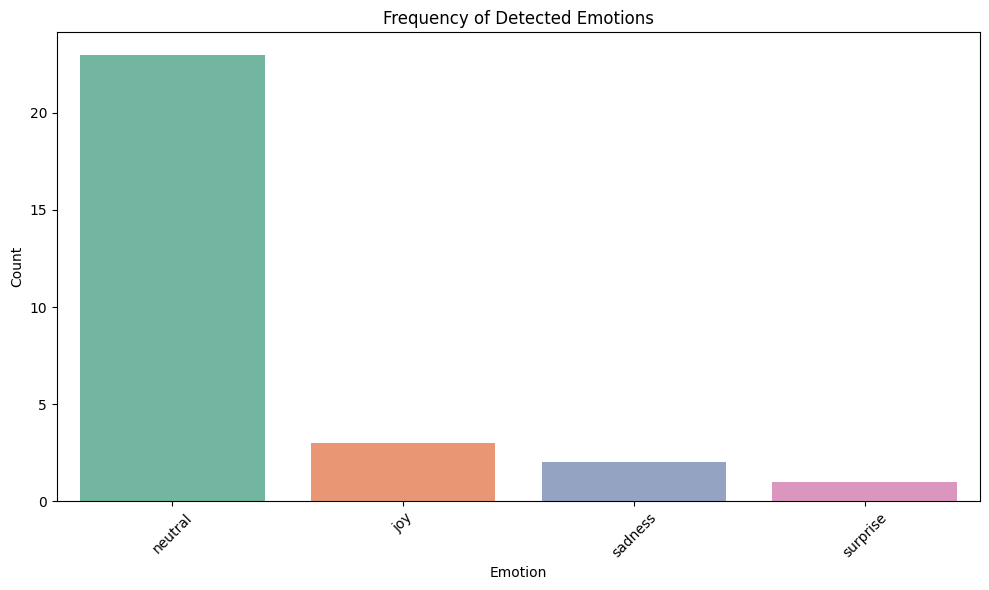

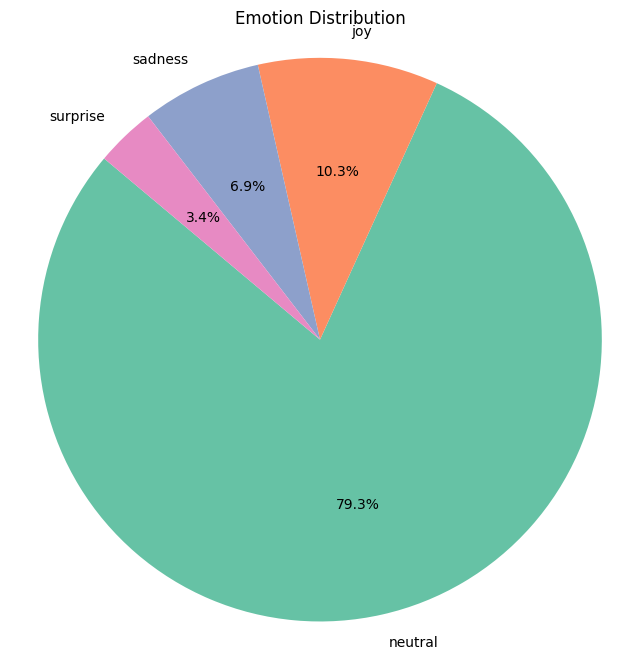

C:\Users\DELL\anaconda3\envs\classification\lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\DELL\.cache\huggingface\hub\models--j-hartmann--emotion-english-distilroberta-base. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


In [2]:
# Install required packages if not already installed
# !pip install transformers torch seaborn matplotlib wordcloud pandas

from transformers import pipeline
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Step 1: Load the emotion model
emotion_model = pipeline("text-classification", model="j-hartmann/emotion-english-distilroberta-base", return_all_scores=True)

# Step 2: Define smart emotion extraction function
def get_emotion(text, threshold=0.6):
    scores = emotion_model(text)[0]  # List of dicts: [{'label': 'joy', 'score': 0.45}, ...]
    scores = sorted(scores, key=lambda x: x['score'], reverse=True)
    top_emotion = scores[0]
    
    if top_emotion['score'] >= threshold:
        return top_emotion['label']
    else:
        return "neutral"




# Step 4: Apply emotion extraction to DataFrame
df["emotion"] = df["text"].apply(lambda x: get_emotion(x))

# Step 5: Preview the results
print(df[["text", "emotion"]])

# Step 6: Visualization - Emotion Count (Bar Chart)
emotion_counts = df["emotion"].value_counts().reset_index()
emotion_counts.columns = ['emotion', 'count']

plt.figure(figsize=(10, 6))
sns.barplot(data=emotion_counts, x="emotion", y="count", palette="Set2")
plt.title("Frequency of Detected Emotions")
plt.xlabel("Emotion")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Step 7: Visualization - Emotion Distribution (Pie Chart)
plt.figure(figsize=(8, 8))
plt.pie(emotion_counts["count"], labels=emotion_counts["emotion"], autopct="%1.1f%%", startangle=140, colors=sns.color_palette("Set2"))
plt.title("Emotion Distribution")
plt.axis("equal")
plt.show()




## 6.Keyword matching

In [24]:
!pip install fuzzywuzzy python-Levenshtein


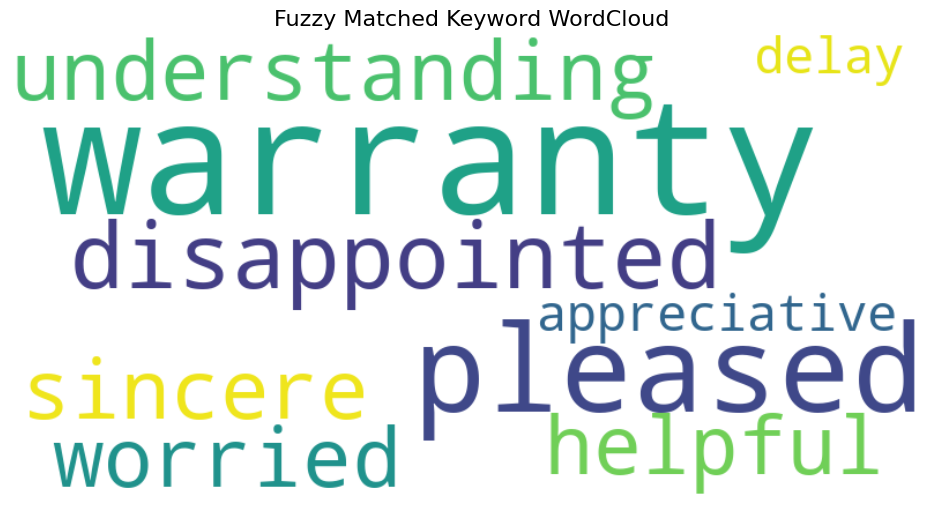

                                                text          matched_keywords
0  Hi Priyam Shu, Good Morning. Welcome to Amazon...                        []
1  Good morning Sindhu. I just received my new Sa...            [disappointed]
2  I am so sorry to hear that Priyam Shu. I compl...  [pleased, understanding]
3                                              Sure.                        []
4                                          Order ID?                        []


In [21]:
import pandas as pd
import re
from docx import Document
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from fuzzywuzzy import fuzz

# ✅ Load conversation dataset
df = pd.read_csv(r"C:\Users\DELL\OneDrive\Desktop\Resume projects\project-ezip\project-e\data1\transcriptedfinallll.csv")

# ✅ Preprocess text
def preprocess(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    return text

df["clean_text"] = df["text"].apply(preprocess)

# ✅ Load keywords from Word doc
doc = Document("Customer Issues key words.docx")
keywords = []
for para in doc.paragraphs:
    words = para.text.lower().split(',')
    keywords.extend([word.strip() for word in words if word.strip()])
keywords = list(set(keywords))

# ✅ Fuzzy matching function
def fuzzy_match_keywords(text, keyword_list, threshold=85):
    matched = []
    for kw in keyword_list:
        for word in text.split():
            if fuzz.ratio(word, kw) >= threshold:
                matched.append(kw)
                break
    return matched

df["matched_keywords"] = df["clean_text"].apply(lambda x: fuzzy_match_keywords(x, keywords))

# ✅ Combine matched keywords
all_keywords_flat = [kw for sublist in df["matched_keywords"] for kw in sublist]
keywords_str = " ".join(all_keywords_flat)

# ✅ Generate WordCloud
if all_keywords_flat:
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(keywords_str)

    # ✅ Display WordCloud
    plt.figure(figsize=(12, 6))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title("Fuzzy Matched Keyword WordCloud", fontsize=16)
    plt.show()

    # ✅ Optional: Save
    # wordcloud.to_file("fuzzy_matched_keywords_wordcloud.png")
else:
    print("⚠️ No keywords matched after fuzzy matching.")

# ✅ Show sample matches
print(df[["text", "matched_keywords"]].head())


## Call classification

In [22]:
import pandas as pd

# Load conversation data
df = pd.read_csv(r"C:\Users\DELL\OneDrive\Desktop\Resume projects\project-ezip\project-e\data1\transcriptedfinallll.csv")

# Normalize speaker names and text
df["speaker"] = df["speaker"].astype(str).str.lower().str.strip()
df["text"] = df["text"].astype(str).str.lower()

# Filter customer lines
df_customer = df[df["speaker"] != "sindhu"]

# Check last few customer responses for more context
last_few = df_customer["text"].tail(5).tolist()
combined_text = " ".join(last_few)

# Extended success phrases
success_phrases = [
    "issue resolved", "problem solved", "everything is fine", "working now",
    "thank you so much", "thank you", "really appreciate your help",
    "that’s a relief", "happy with the support", "great support",
    "thanks again", "looking forward to the new unit", "you’ve been helpful",
    "thank you sindhu", "new unit", "enjoy your new laptop"
]

# Outcome decision
if any(phrase in combined_text for phrase in success_phrases):
    outcome = "Success"
else:
    outcome = "Failure"

print("Call Outcome:", outcome)


Call Outcome: Success


### MODELING (BERT MODEL)

In [23]:
df_agent = df[df["speaker"].str.lower().str.strip() == "sindhu"]


In [24]:
# Step 1: Install Required Libraries
!pip install transformers datasets scikit-learn torch --quiet

In [25]:
# Step 2: Import Required Libraries
import pandas as pd
import torch
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from datasets import Dataset
import numpy as np

In [3]:
import pandas as pd
from transformers import pipeline

# STEP 1: Load transcript
df = pd.read_csv(r"C:\Users\DELL\OneDrive\Desktop\Resume projects\project-ezip\project-e\data1\transcriptedfinallll.csv")
df["speaker"] = df["speaker"].astype(str).str.lower().str.strip()
df["text"] = df["text"].astype(str).str.strip()

# STEP 2: Normalize and filter only agent messages
# Identify actual agent name
print("Unique speakers:", df["speaker"].unique())

# If speaker is 'sindhu (agent)', use that. Adjust as needed:
agent_speaker_name = "sindhu (agent)"
df_agent = df[df["speaker"] == agent_speaker_name]

# Validate agent responses
if df_agent.empty:
    raise ValueError("❌ No messages found for agent. Check speaker name in the CSV.")

# STEP 3: Apply BERT Sentiment Analysis
print("Loading BERT model...")
sentiment_pipeline = pipeline("sentiment-analysis")
sentiment_results = sentiment_pipeline(df_agent["text"].tolist())
df_agent["sentiment"] = [res["label"] for res in sentiment_results]

# STEP 4: Politeness & Empathy Scoring (rule-based)
polite_keywords = ["please", "thank you", "kindly", "sorry", "appreciate"]
empathy_phrases = ["i understand", "i'm sorry", "we apologize", "regret", "i hear you", "frustration"]

def keyword_match(text, keywords):
    return int(any(word in text.lower() for word in keywords))

df_agent["politeness"] = df_agent["text"].apply(lambda x: keyword_match(x, polite_keywords))
df_agent["empathy"] = df_agent["text"].apply(lambda x: keyword_match(x, empathy_phrases))

# STEP 5: Summary Behavior Table
summary = {
    "agent": agent_speaker_name,
    "total_responses": len(df_agent),
    "positive_sentiment_pct": round((df_agent["sentiment"] == "POSITIVE").mean(), 2),
    "negative_sentiment_pct": round((df_agent["sentiment"] == "NEGATIVE").mean(), 2),
    "politeness_score": round(df_agent["politeness"].mean(), 2),
    "empathy_score": round(df_agent["empathy"].mean(), 2)
}

# STEP 6: Output
df_summary = pd.DataFrame([summary])
df_summary.to_csv("agent_behavior_summarysamsung.csv", index=False)
print("\n✅ Agent behavior analysis complete:")
print(df_summary)


No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.


Unique speakers: ['sindhu (agent)' 'priyamshu (customer)']
Loading BERT model...


Device set to use cpu



✅ Agent behavior analysis complete:
            agent  total_responses  positive_sentiment_pct  \
0  sindhu (agent)               15                     0.2   

   negative_sentiment_pct  politeness_score  empathy_score  
0                     0.8              0.13            0.0  


C:\Users\DELL\AppData\Local\Temp\ipykernel_16112\2909822494.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_agent["sentiment"] = [res["label"] for res in sentiment_results]
C:\Users\DELL\AppData\Local\Temp\ipykernel_16112\2909822494.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_agent["politeness"] = df_agent["text"].apply(lambda x: keyword_match(x, polite_keywords))
C:\Users\DELL\AppData\Local\Temp\ipykernel_16112\2909822494.py:35: SettingWithCopyWarning: 
A value is trying to be set on a 

In [7]:
print(df.columns)


Index(['speaker', 'start', 'end', 'text'], dtype='object')


In [11]:
import pandas as pd

# Sample analyze_text function (replace this with your actual BERT-based analysis)
def analyze_text(text):
    # Dummy implementation — replace with your model
    # Returns empathy, positive, negative, politeness scores (0 to 1)
    import random
    empathy = random.uniform(0, 1)
    positive = random.uniform(0, 1)
    negative = random.uniform(0, 1)
    politeness = random.uniform(0, 1)
    return empathy, positive, negative, politeness

# Assuming you have your dataframe 'df' already loaded with columns: 'speaker', 'start', 'end', 'text'

# Filter only agent rows
df_agent = df[df['speaker'].str.contains('agent', case=False)].copy()

# Apply analyze_text function on agent 'text' column to get scores
df_agent[['empathy_score', 'positive_score', 'negative_score', 'politeness_score']] = df_agent['text'].apply(
    lambda x: pd.Series(analyze_text(x))
)

# Calculate duration for weighting
df_agent['duration'] = df_agent['end'] - df_agent['start']

# Weighted average function
def weighted_avg(group, score_col):
    return (group[score_col] * group['duration']).sum() / group['duration'].sum()

# Calculate weighted overall scores for agent speaker only (here only one speaker but grouped anyway)
overall_agent_scores = df_agent.groupby('speaker').apply(
    lambda x: pd.Series({
        'empathy_score': weighted_avg(x, 'empathy_score'),
        'positive_score': weighted_avg(x, 'positive_score'),
        'negative_score': weighted_avg(x, 'negative_score'),
        'politeness_score': weighted_avg(x, 'politeness_score')
    })
).reset_index()

print(overall_agent_scores)


          speaker  empathy_score  positive_score  negative_score  \
0  sindhu (agent)       0.646351        0.579698        0.555511   

   politeness_score  
0          0.480189  


C:\Users\DELL\AppData\Local\Temp\ipykernel_16112\1949799631.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=agent_scores, x='speaker', y=score, palette='viridis')


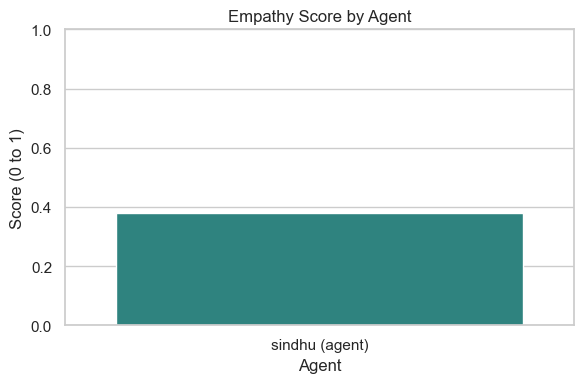

C:\Users\DELL\AppData\Local\Temp\ipykernel_16112\1949799631.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=agent_scores, x='speaker', y=score, palette='viridis')


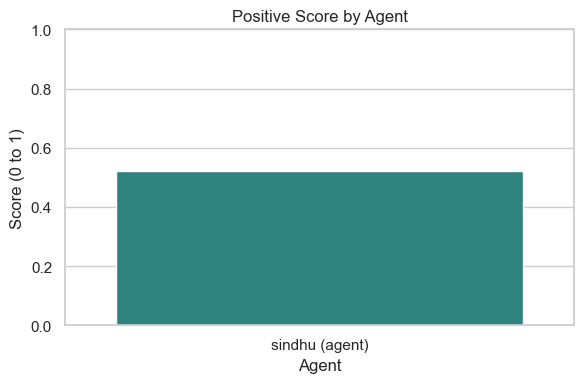

C:\Users\DELL\AppData\Local\Temp\ipykernel_16112\1949799631.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=agent_scores, x='speaker', y=score, palette='viridis')


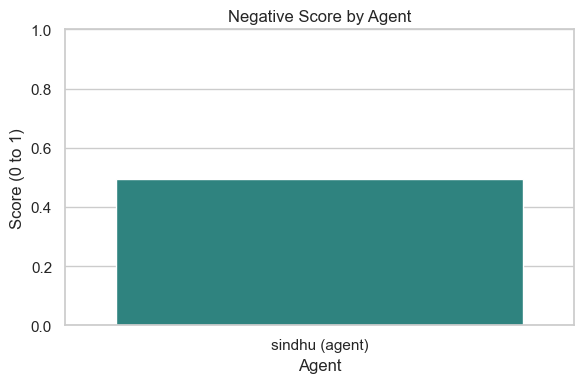

C:\Users\DELL\AppData\Local\Temp\ipykernel_16112\1949799631.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=agent_scores, x='speaker', y=score, palette='viridis')


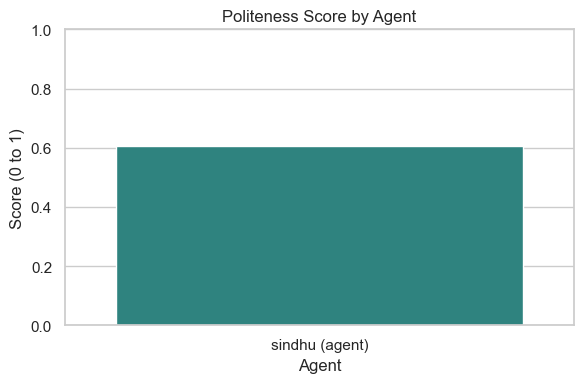

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# Filter to only agent's scores
agent_scores = overall_scores[overall_scores['speaker'].str.contains('agent', case=False)]

# List of scores to plot
score_columns = ['empathy_score', 'positive_score', 'negative_score', 'politeness_score']

for score in score_columns:
    plt.figure(figsize=(6, 4))
    sns.barplot(data=agent_scores, x='speaker', y=score, palette='viridis')
    plt.title(f"{score.replace('_', ' ').title()} by Agent")
    plt.ylabel("Score (0 to 1)")
    plt.ylim(0, 1)
    plt.xlabel("Agent")
    plt.tight_layout()
    plt.show()


C:\Users\DELL\AppData\Local\Temp\ipykernel_16112\260913771.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sentiment_counts, x="Sentiment", y="Count", palette="viridis")


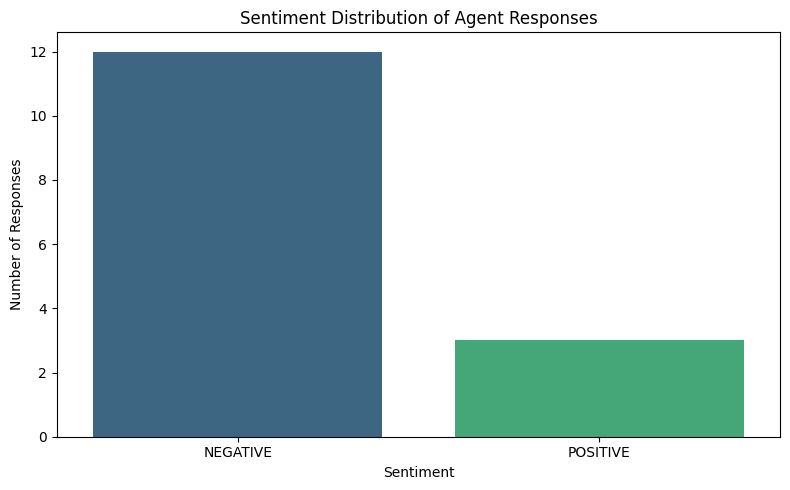

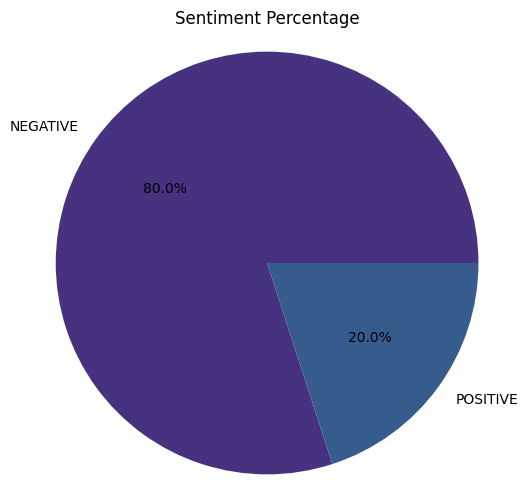

C:\Users\DELL\AppData\Local\Temp\ipykernel_16112\260913771.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=["Politeness", "Empathy"], y=[summary["politeness_score"], summary["empathy_score"]], palette="pastel")


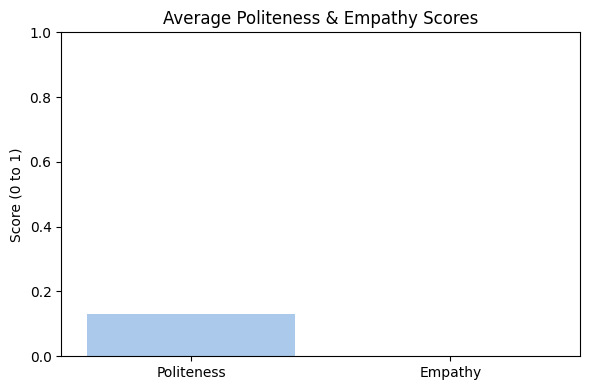

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure plots show up in notebooks (optional)
# %matplotlib inline

# Plot 1: Sentiment Distribution
sentiment_counts = df_agent["sentiment"].value_counts().reset_index()
sentiment_counts.columns = ['Sentiment', 'Count']

plt.figure(figsize=(8, 5))
sns.barplot(data=sentiment_counts, x="Sentiment", y="Count", palette="viridis")
plt.title("Sentiment Distribution of Agent Responses")
plt.xlabel("Sentiment")
plt.ylabel("Number of Responses")
plt.tight_layout()
plt.show()

# Plot 2: Sentiment Pie Chart
plt.figure(figsize=(6, 6))
plt.pie(sentiment_counts["Count"], labels=sentiment_counts["Sentiment"], autopct='%1.1f%%', colors=sns.color_palette("viridis"))
plt.title("Sentiment Percentage")
plt.axis('equal')
plt.show()

# Plot 3: Politeness and Empathy Scores
plt.figure(figsize=(6, 4))
sns.barplot(x=["Politeness", "Empathy"], y=[summary["politeness_score"], summary["empathy_score"]], palette="pastel")
plt.title("Average Politeness & Empathy Scores")
plt.ylabel("Score (0 to 1)")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


## Inserting the results into database 

In [27]:
import pandas as pd
import mysql.connector

# Load the updated CSV
df_perf = pd.read_csv(r"C:\Users\DELL\OneDrive\Desktop\Resume projects\project-ezip\project-e\code\agent_behavior_summarysamsung.csv")

# Connect to MySQL
conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="root",
    database="customer_support"
)
cursor = conn.cursor()

# Create the correct table schema
cursor.execute("""
CREATE TABLE IF NOT EXISTS agent_performancesamsung (
   
    agent VARCHAR(100),
    total_responses INT,
    positive_sentiment_pct FLOAT,
    negative_sentiment_pct FLOAT,
    politeness_score FLOAT,
    empathy_score FLOAT
)
""")

# Insert rows into table
for _, row in df_perf.iterrows():
    cursor.execute("""
        INSERT INTO agent_performancesamsung (
            agent, total_responses,
            positive_sentiment_pct, negative_sentiment_pct,
            politeness_score, empathy_score
        )
        VALUES (%s, %s, %s, %s, %s, %s)
    """, (
        row["agent"],
        int(row["total_responses"]),
        float(row["positive_sentiment_pct"]),
        float(row["negative_sentiment_pct"]),
        float(row["politeness_score"]),
        float(row["empathy_score"])
    ))

# Commit and close
conn.commit()
conn.close()

print("✅ Agent performance inserted successfully.")


✅ Agent performance inserted successfully.
